In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
honey_df = pd.read_csv('honeyproduction1998-2016-2.csv')

### Initial diagnosis

In [6]:
honey_df.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,Alabama,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,Arizona,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,Arkansas,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,California,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,Colorado,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


In [7]:
honey_df.shape

(785, 8)

In [9]:
honey_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        785 non-null    object 
 1   numcol       785 non-null    float64
 2   yieldpercol  785 non-null    int64  
 3   totalprod    785 non-null    float64
 4   stocks       785 non-null    float64
 5   priceperlb   785 non-null    float64
 6   prodvalue    785 non-null    float64
 7   year         785 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 49.2+ KB


In [12]:
honey_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
state,785,44,Alabama,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
numcol,785.0,NaN,NaN,NaN,61686.624204,92748.940458,2000.0,9000.0,26000.0,65000.0,510000.0
yieldpercol,785.0,NaN,NaN,NaN,60.578344,19.427831,19.0,46.0,58.0,72.0,136.0
totalprod,785.0,NaN,NaN,NaN,4140956.687898,6884593.858766,84000.0,470000.0,1500000.0,4096000.0,46410000.0
stocks,785.0,NaN,NaN,NaN,1257629.299363,2211793.817061,8000.0,119000.0,391000.0,1380000.0,13800000.0
priceperlb,785.0,NaN,NaN,NaN,1.695159,0.930623,0.49,1.05,1.48,2.04,7.09
prodvalue,785.0,NaN,NaN,NaN,5489738.853503,9425393.878217,162000.0,901000.0,2112000.0,5559000.0,83859000.0
year,785.0,NaN,NaN,NaN,2006.817834,5.491523,1998.0,2002.0,2007.0,2012.0,2016.0


##### Raw facts

1. No missing values observed across the dataset
2. There are 44 unique states in the dataset
3. The median number of col is 26000, with a huge std dev ~93000 indicating the distribution is heavily skewed with some states having large colony counts
4. average Yield per col is ~60 pounds, the max value is nearly 2x the 75th percentile indicating there are some high yield colonies(outliers are already removed in this dataset)
5. Total prod also appears to have a high std dev
6. Price per lb shows a wide range (0.49 to 7.09), indicating significant variability. Further analysis over time is needed to confirm trends.
7. Prod value also exhibits high variability (std dev ~9.4M vs mean ~5.4M), indicating uneven contribution across states/years.
8. The data is recorded from 1998-2016


## Univariate Analysis of numerical columns

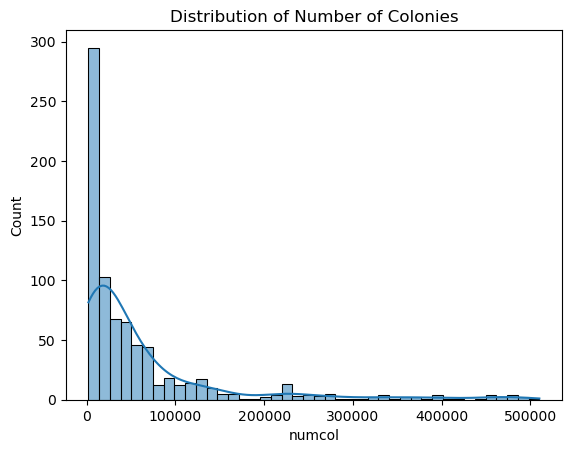

In [21]:
sns.histplot(data=honey_df, x='numcol', kde=True);
plt.title('Distribution of Number of Colonies');

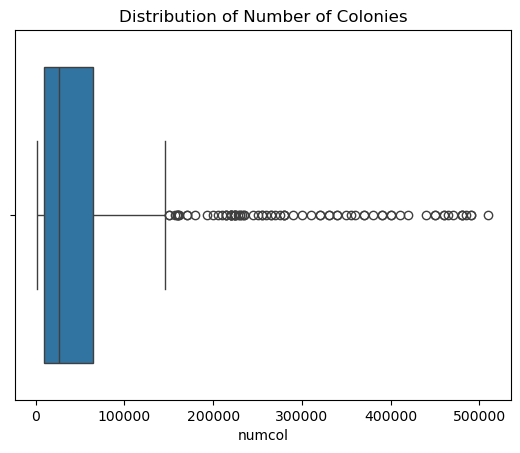

In [22]:
sns.boxplot(data=honey_df, x='numcol')
plt.title('Distribution of Number of Colonies');

1. The distribution is heavily right skewed
2. Most of the colony is clustered in the range $ 2000-65000(IQR) and a few large colonies pulling the tail towards right

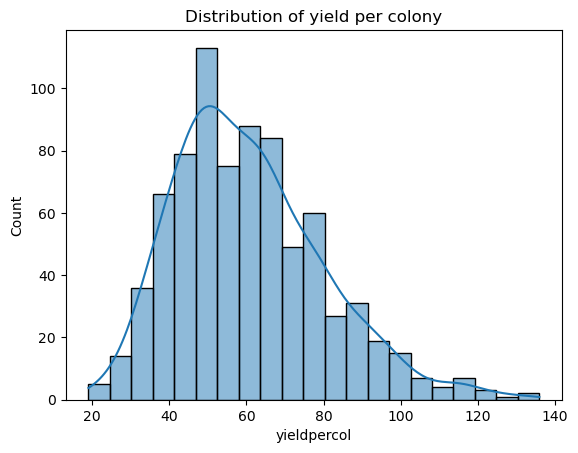

In [27]:
sns.histplot(data=honey_df, x='yieldpercol', kde=True)
plt.title('Distribution of yield per colony');

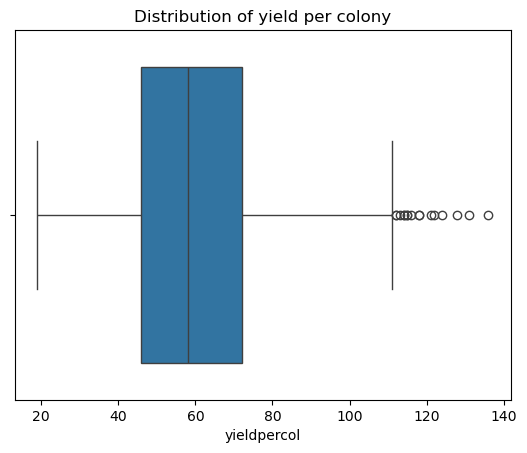

In [28]:
sns.boxplot(data=honey_df, x='yieldpercol')
plt.title('Distribution of yield per colony');

1. The distribution is slightly right skewed
2. Yield per colony commonly falls in the range 46-72 pounds (IQR), with a few higher values (110+) pulling the distribution to the right
4. The median yield is closed to 60 pounds

Text(0.5, 1.0, 'Distribution of Total production')

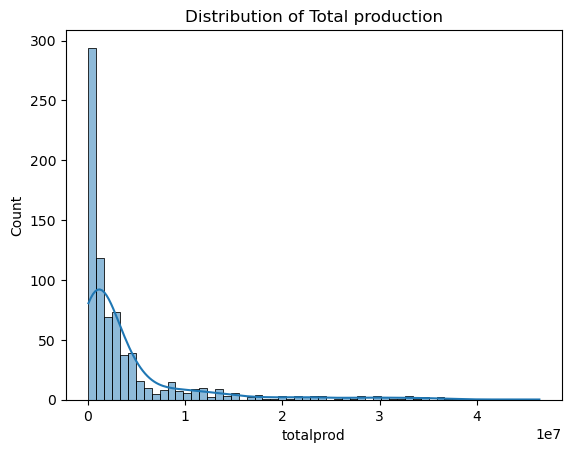

In [41]:
sns.histplot(data=honey_df, x='totalprod', kde=True)
plt.title('Distribution of Total production')


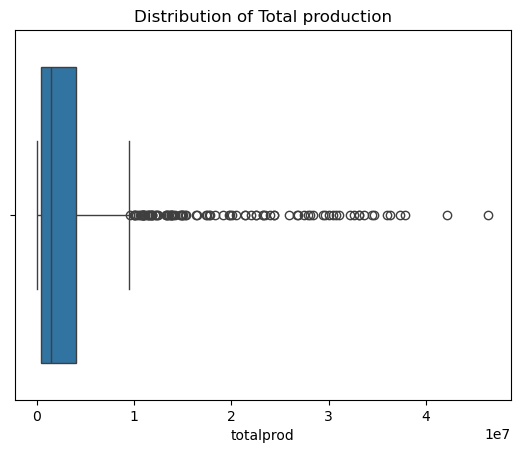

In [32]:
sns.boxplot(data=honey_df, x='totalprod')
plt.title('Distribution of Total production');

1. The distribution is heavily right skewed, small number of higher values stretching the distribution to the right
2. The middle 50% of the values fall in the range 470000 - 4096000 pounds (IQR)
3. The median total product is ~1.5M pounds

Text(0.5, 1.0, 'Distribution of Stocks')

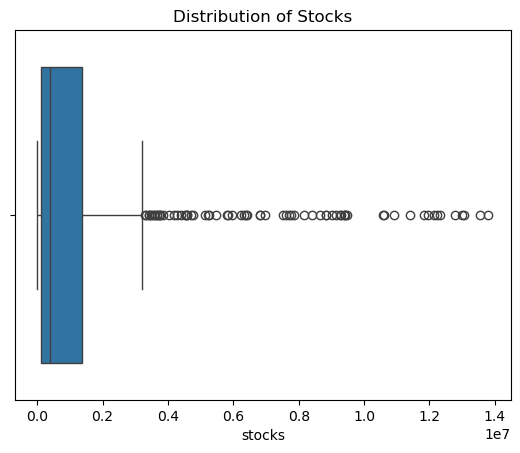

In [46]:
sns.boxplot(data=honey_df, x='stocks')
plt.title('Distribution of Stocks')

1. The distribution is heavily right skewed, with small number of higher values pulling the tail to right
2. The median level of stock is ~391K
3. The middle 50% of the values fall in the range ~ 119k to 1.38M

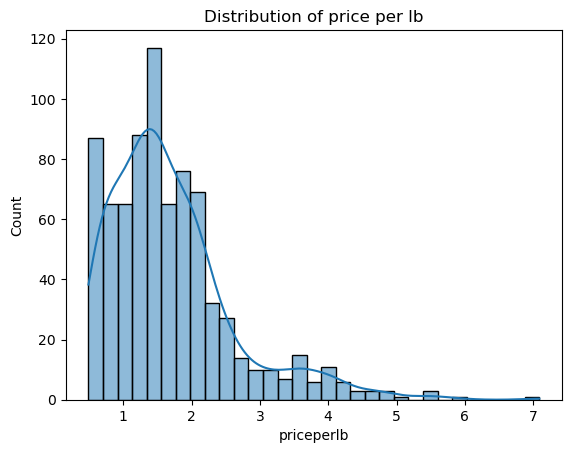

In [50]:
sns.histplot(data=honey_df, x='priceperlb', kde=True)
plt.title('Distribution of price per lb');

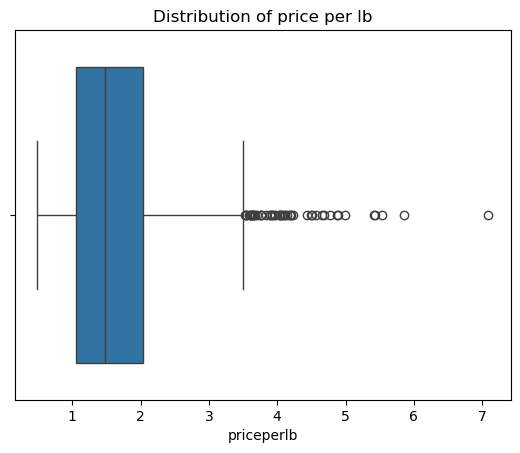

In [51]:
sns.boxplot(data=honey_df, x='priceperlb')
plt.title('Distribution of price per lb');

1. 25% of the recorded priceperlb is low ~ 1 dollar
2. The middle 50% of values lie between ~ USD 1 and ~ USD 2.
3. The distribution is heavily right skewed with a long tail extended beyong ~3.5 dollars
4. The median price per lb is ~1.5 dollars

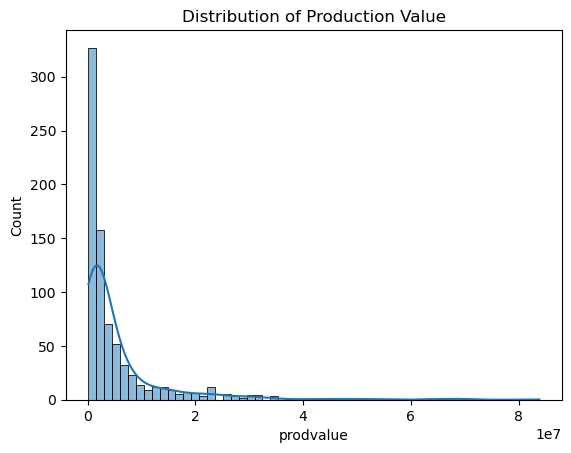

In [52]:
sns.histplot(data=honey_df, x='prodvalue', kde=True)
plt.title('Distribution of Production Value');

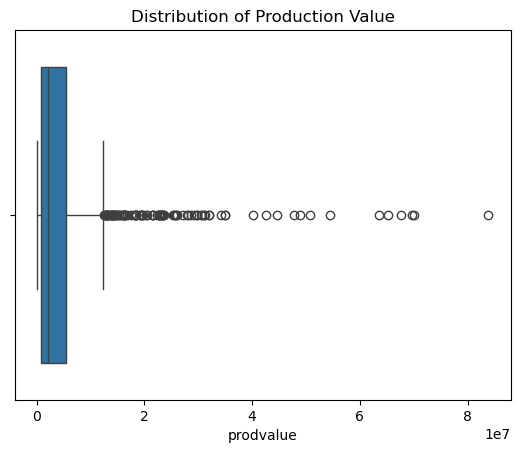

In [53]:
sns.boxplot(data=honey_df, x='prodvalue')
plt.title('Distribution of Production Value');

1. The distribution is heavily right skeweed with a small number of high production value extending the long tail
2. The middle 50% of the values falls in the range ~0.9M to 5.5M(IQR)
3. The median production value is ~ 2M, while the high standard deviation (~9M) indicates substantial variability across observations

## Bivariate Analysis

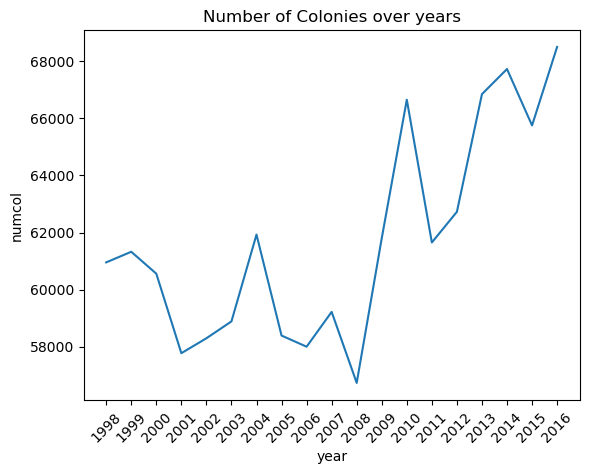

In [68]:
sns.lineplot(data=honey_df, x='year', y='numcol', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Number of Colonies over years');

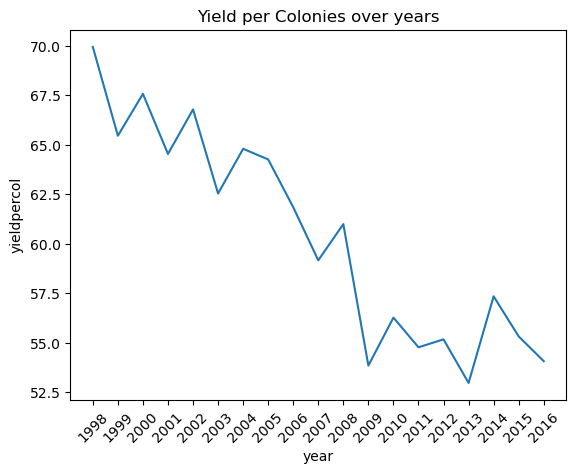

In [69]:
sns.lineplot(data=honey_df, x='year', y='yieldpercol', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Yield per Colonies over years');

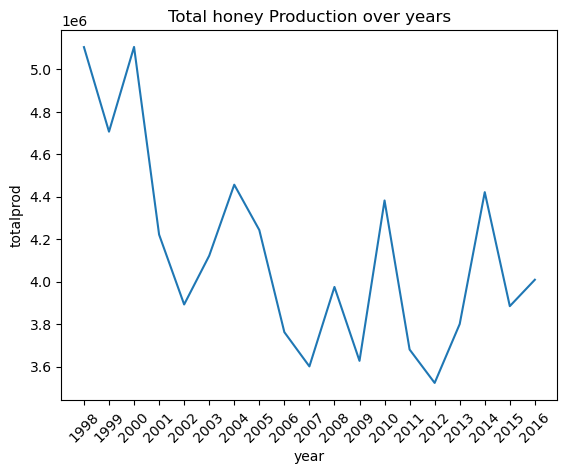

In [73]:
sns.lineplot(data=honey_df, x='year', y='totalprod', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Total honey Production over years');

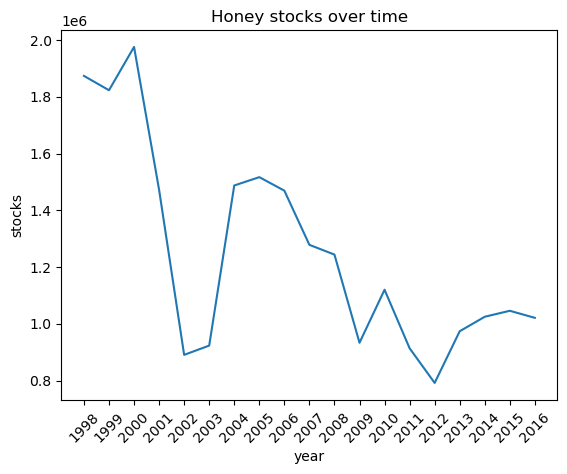

In [72]:
sns.lineplot(data=honey_df, x='year', y='stocks', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Honey stocks over time');

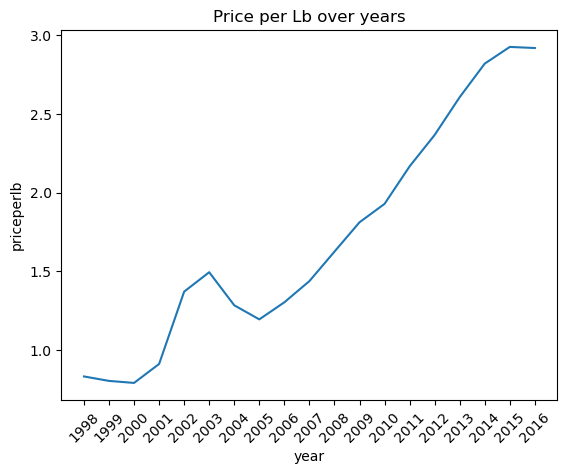

In [74]:
sns.lineplot(data=honey_df, x='year', y='priceperlb', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Price per Lb over years');

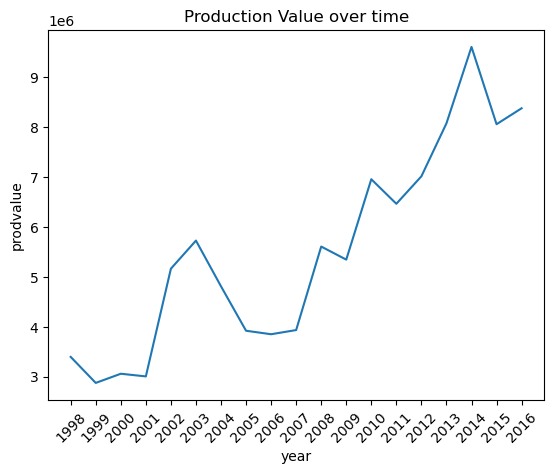

In [75]:
sns.lineplot(data=honey_df, x='year', y='prodvalue', errorbar=None)
plt.xticks(sorted(honey_df['year'].unique()), rotation=45);
plt.title('Production Value over time');

1. Number of colonies show fluctuations in the early years, followed by a steady increase after ~2008
2. Yield per colony shows a declining trend, showing a noticeable drop around~2008-2009
3. Total Production fluctuates over the years without a clear upward/downward trend
4. Stocks show an overall declining trend, especially after early 2000s
5. Price per lB shows a clear upward trend over the years, with sharp increase after ~2008
6. Production Value shows a upward trend over the years aligning with the rise in Price

In [167]:
corr_matrix = honey_df[['yieldpercol', 'totalprod','stocks', 'priceperlb', 'prodvalue']].corr()
corr_matrix

,yieldpercol,totalprod,stocks,priceperlb,prodvalue
yieldpercol,1.000000,0.382945,0.358676,-0.360571,0.255789
totalprod,0.382945,1.000000,0.876872,-0.239085,0.895242
stocks,0.358676,0.876872,1.000000,-0.275926,0.713161
priceperlb,-0.360571,-0.239085,-0.275926,1.000000,-0.061833
prodvalue,0.255789,0.895242,0.713161,-0.061833,1.000000


<Axes: >

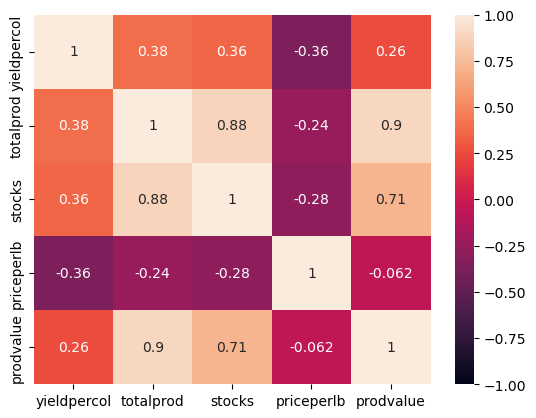

In [91]:
sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True)

1. Price per lb shows a negative correlation with stocks and Yieldpercol, indicating that lower supply is associated with higher prices
2. Stocks and Production value show a strong positive correlation, suggesting that higher stocks align with higher production value
3. Yield per colony is positively correlated with stocks, showing that supply depends on productivity
4. Price per lb has a negative correlation with production value, suggesting that higher prices may coincide with lower overall production value.
5. Total Production shows a negative correlation with Price per lb, suggesting that higher supply is associated with lower prices.

Priceperlb shows negative correlation with stock related variables like Stocks, Yieldpercol, totalprod. 

<Axes: xlabel='totalprod', ylabel='priceperlb'>

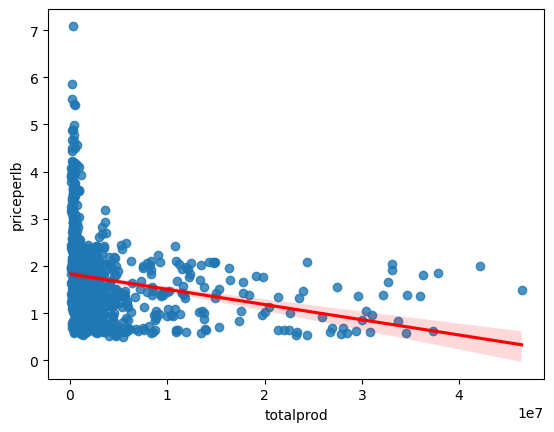

In [103]:
sns.regplot(data=honey_df, x='totalprod', y='priceperlb', line_kws={'color': 'red'})


<Axes: xlabel='stocks', ylabel='priceperlb'>

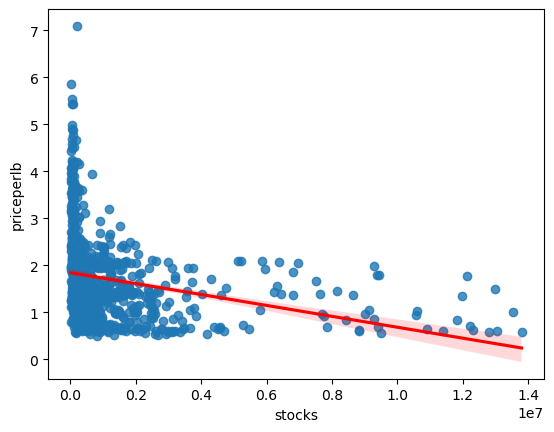

In [100]:
sns.regplot(data=honey_df, x='stocks', y='priceperlb',line_kws={'color': 'red'} )

<Axes: xlabel='yieldpercol', ylabel='priceperlb'>

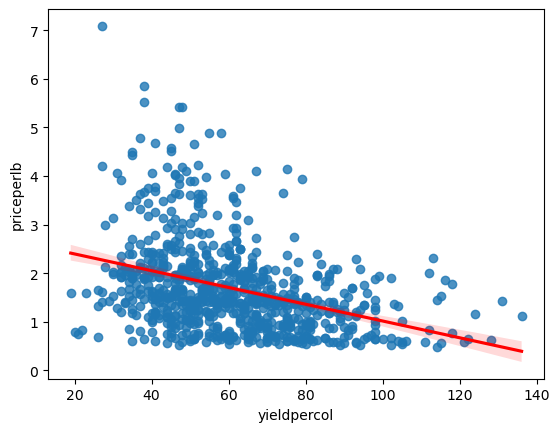

In [101]:
sns.regplot(data=honey_df, x='yieldpercol', y='priceperlb', line_kws={'color': 'red'})

### Priceperlb shows negative correlation with stock related variables like Stocks, Yieldpercol, totalprod. This indicates a consistent supply-price pattern.

## Breaking the year by CCD phase (Pre, Transition and Post)

In [104]:
def label_year(year):
    if year < 2006:
        return 'Pre CCD'
    elif year <= 2009:
        return 'Transition'
    else:
        return 'Post CCD'

honey_df['ccd_phase'] = honey_df['year'].apply(label_year)

In [105]:
honey_df.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year,ccd_phase
0,Alabama,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998,Pre CCD
1,Arizona,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998,Pre CCD
2,Arkansas,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998,Pre CCD
3,California,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998,Pre CCD
4,Colorado,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998,Pre CCD


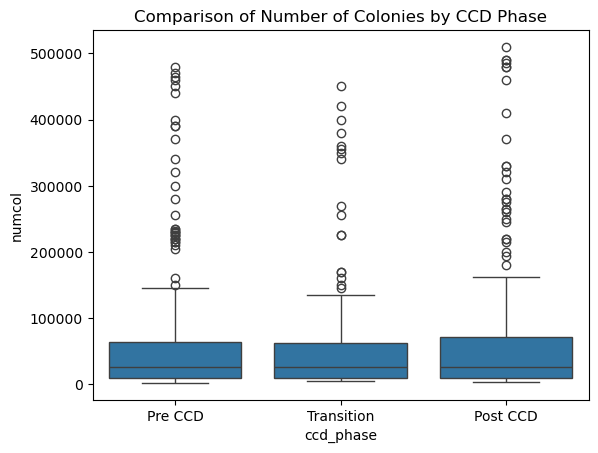

In [169]:
sns.boxplot(data=honey_df, x='ccd_phase', y='numcol');
plt.title('Comparison of Number of Colonies by CCD Phase');

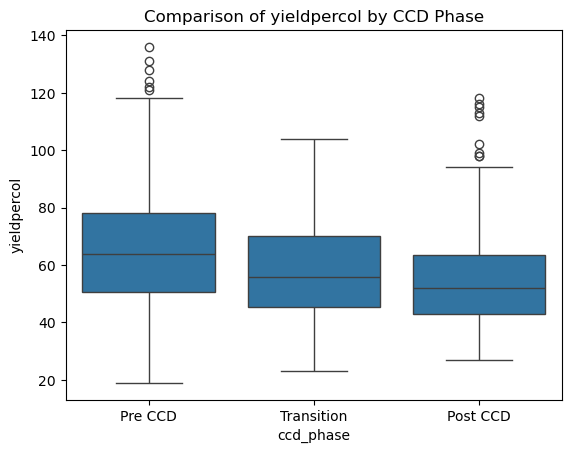

In [171]:
sns.boxplot(data=honey_df, x='ccd_phase', y='yieldpercol');
plt.title('Comparison of yieldpercol by CCD Phase');

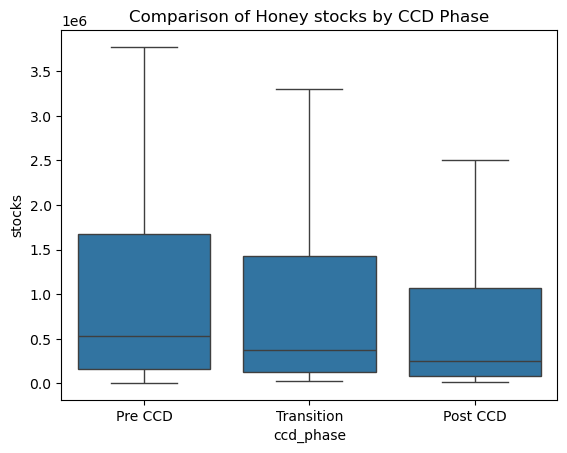

In [172]:
sns.boxplot(data=honey_df, x='ccd_phase', y='stocks', showfliers=False);
plt.title('Comparison of Honey stocks by CCD Phase');

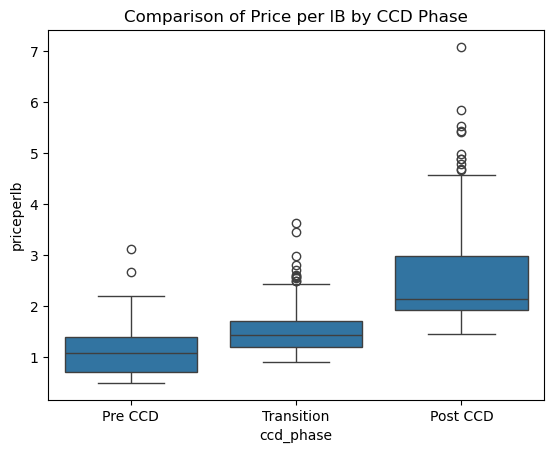

In [173]:
sns.boxplot(data=honey_df, x='ccd_phase', y='priceperlb');
plt.title('Comparison of Price per lB by CCD Phase');


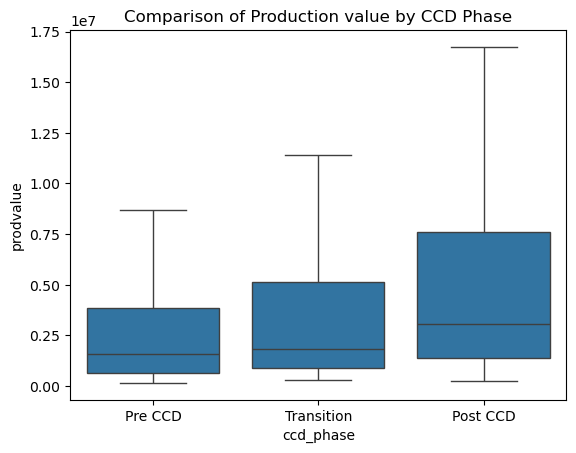

In [174]:
sns.boxplot(data=honey_df, x='ccd_phase', y='prodvalue', showfliers=False);
plt.title('Comparison of Production value by CCD Phase');

### Following CCD (post-2006), yield per colony declined, indicating reduced biological productivity. However, production value increased over time, driven primarily by rising prices rather than improvements in output.

Summary:
The dataset shows strong right-skew across key variables, indicating concentration among a few states. Post-CCD, yield per colony declines while production value increases, driven primarily by rising prices. This suggests a price-compensated response to supply-side pressures, with variability across states.


Next Steps:
State-level analysis to examine geographic variation in production trends and CCD impact.

### State Level Analysis

In [234]:
top_states = honey_df.groupby('state')['totalprod'].sum().nlargest(10).reset_index()

Text(0.5, 1.0, 'Top 10 States by Total Honey Production - Overall')

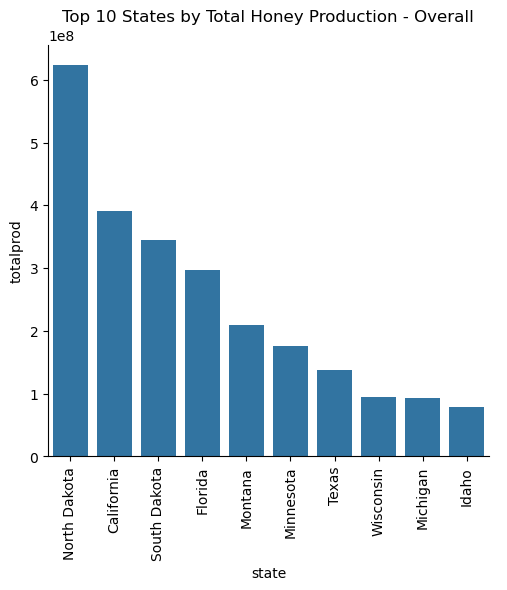

In [190]:
sns.catplot(
    data=top_states,
    x='state',
    y='totalprod',
    kind='bar'
)
plt.xticks(rotation=90);
plt.title('Top 10 States by Total Honey Production - Overall')

In [182]:
bottom_states = honey_df.groupby('state')['totalprod'].sum().nsmallest(10).reset_index()

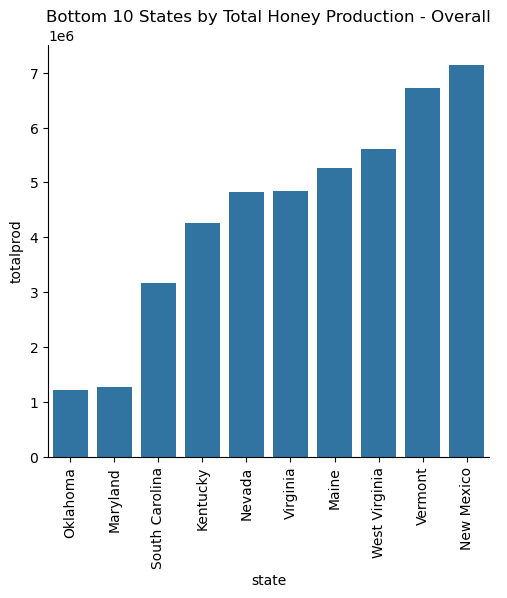

In [192]:
sns.catplot(
    data=bottom_states,
    x='state',
    y='totalprod',
    kind='bar'
)
plt.xticks(rotation=90)
plt.title('Bottom 10 States by Total Honey Production - Overall');

1. North Dakota is the highest honey producer, followed by California and South Dakota, indicating strong regional concentration in production.
2. Oklahoma produces the least honey, followed by Maryland and South Carolina, indicating minimal contribution from these states.


### Honey production is highly concentrated, with a few states contributing the majority of output while several states have minimal contribution.

In [194]:
costly_honey = honey_df.groupby('state')['priceperlb'].mean().nlargest(10).reset_index()
costly_honey

,state,priceperlb
0,Virginia,2.913684
1,South Carolina,2.761667
2,Illinois,2.656316
3,North Carolina,2.503158
4,Kentucky,2.447895
5,Tennessee,2.349474
6,West Virginia,2.295263
7,Nevada,2.219091
8,New Jersey,2.171053
9,Vermont,2.127895


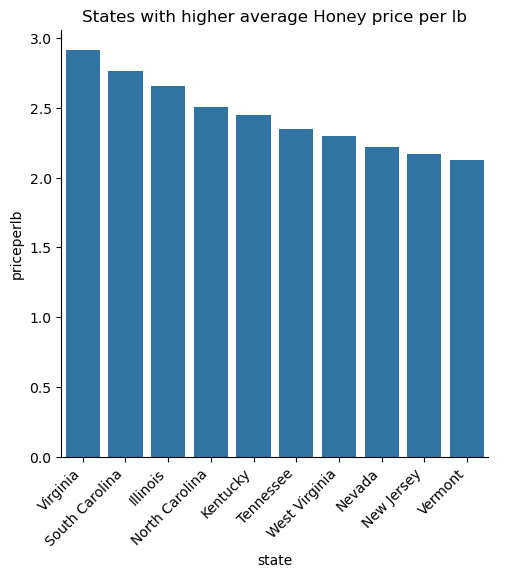

In [197]:
sns.catplot(
    data=costly_honey,
    x='state',
    y='priceperlb',
    kind='bar'
)

plt.xticks(rotation=45, ha='right')
plt.title('States with higher average Honey price per lb');

### This chart shows the top 10 states with the highest average honey price per pound. These higher prices may be associated with lower production levels or limited supply in these states.

In [252]:
cheap_honey = honey_df.groupby('state')['priceperlb'].mean().nsmallest(10).reset_index()


Text(0.5, 1.0, '10 States with Cheapest Average honey price per lb')

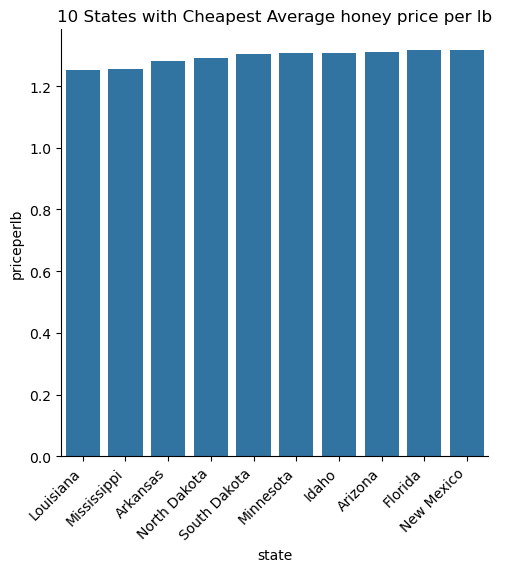

In [254]:
sns.catplot(data=cheap_honey, x='state', y='priceperlb', kind='bar')
plt.xticks(rotation=45, ha='right')
plt.title('10 States with Cheapest Average honey price per lb')

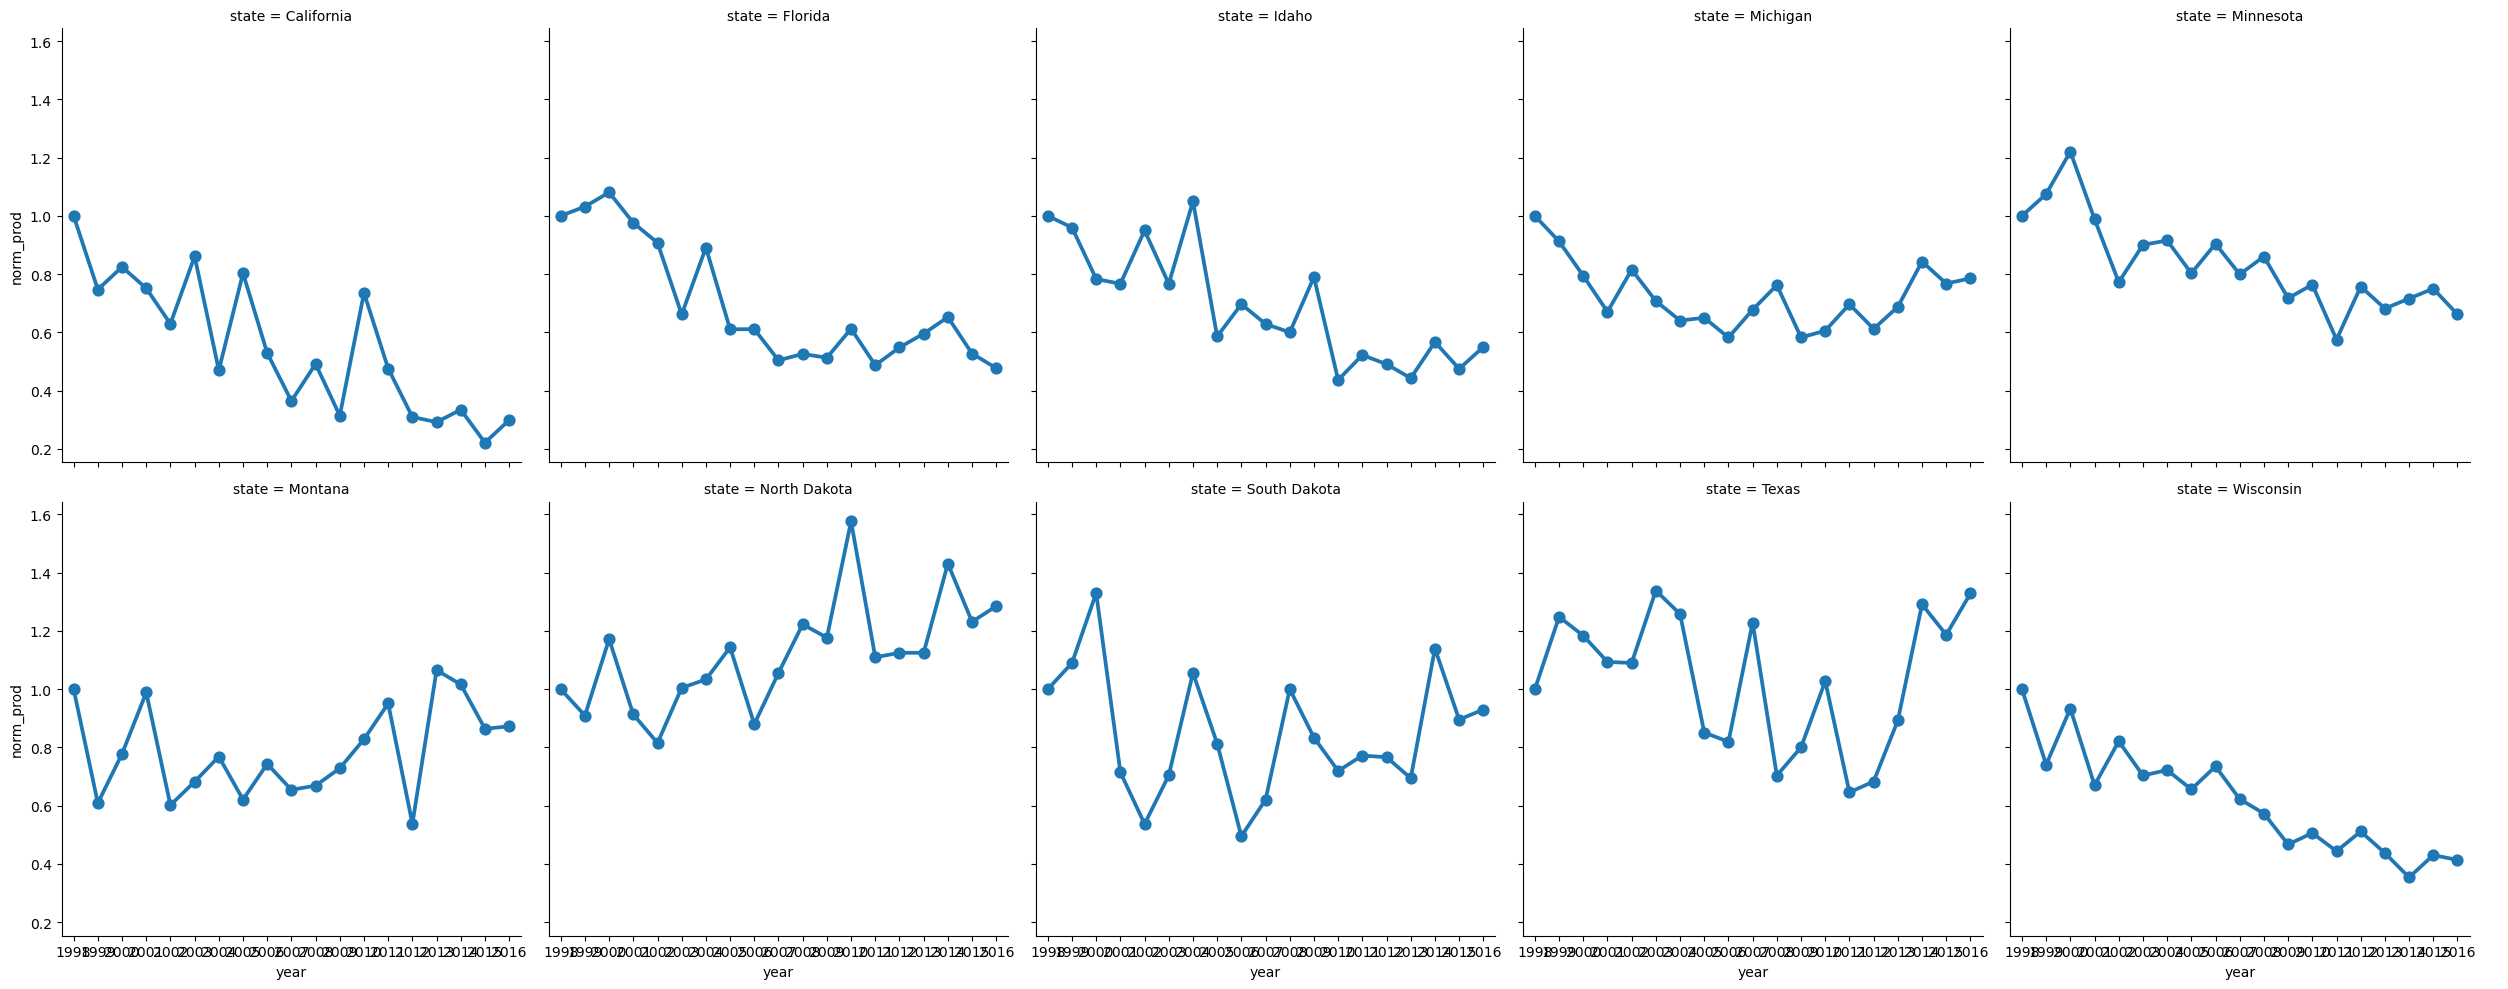

In [249]:
# Normalising the totalprod to compare the trend with other states. Dividing the first value of a group with each group member to obtain normalised value
# transform() to apply changes to each row in a group

top_10_trend = honey_df[ honey_df['state'].isin(top_states['state'])].copy()
top_10_trend['norm_prod'] = (
    top_10_trend.groupby('state')['totalprod']
    .transform(lambda x: x / x.iloc[0])
)


sns.catplot(x='year', y='norm_prod', data=top_10_trend,
                col='state', kind="point",
              col_wrap = 5);


1. Total Production in North Dakota shows a strong upward trend
2. Total Productions collapses with time in California and Floria
3. Michigan and Minnesota shows a mild decline but stabilise with time
4. Montana, South Dakota, Texas and idaho is volatile, no clear trend

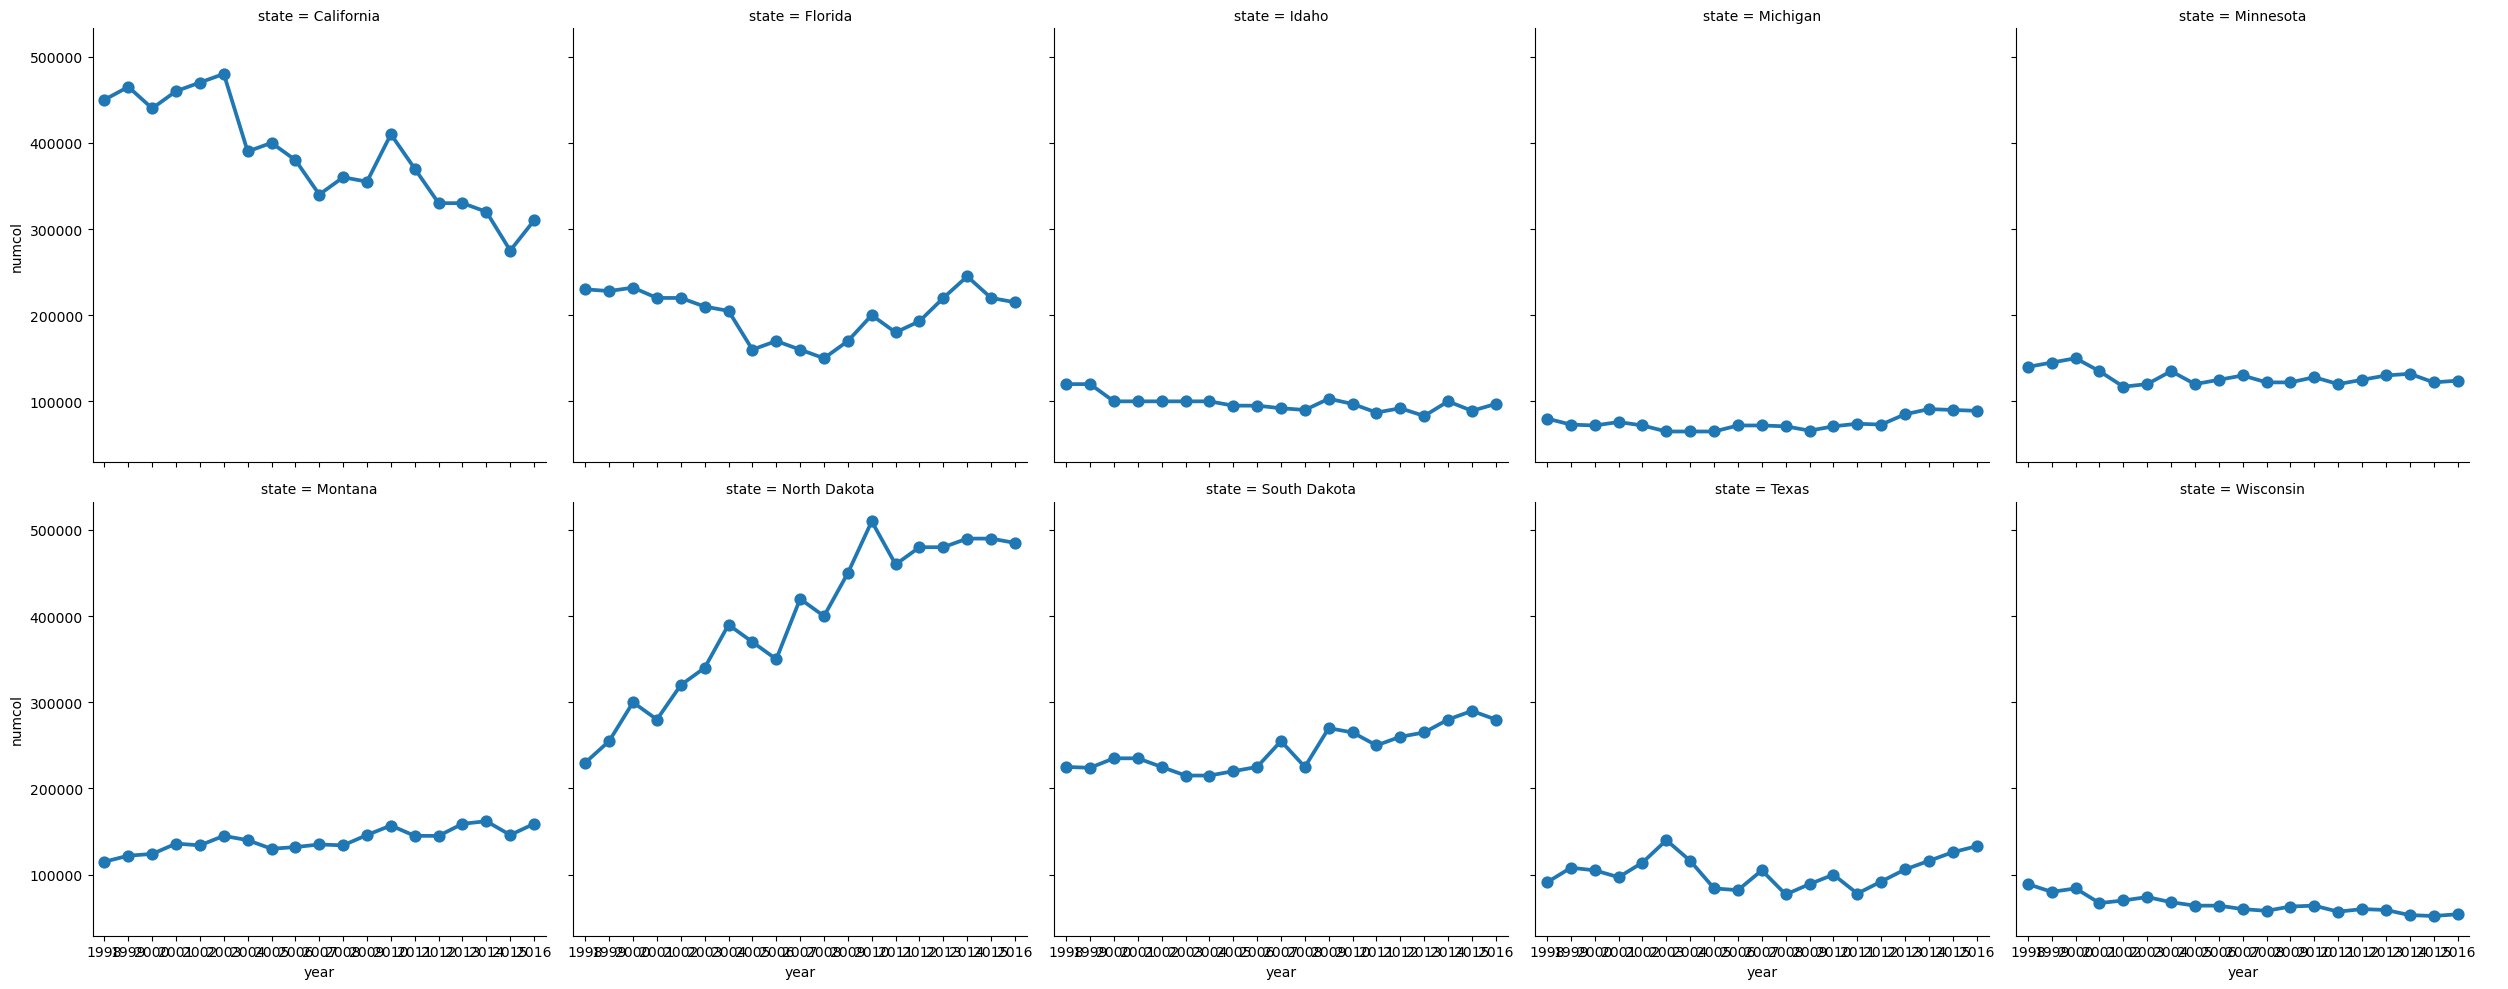

In [257]:
sns.catplot(data=top_10_trend, x='year', y='numcol', col='state', kind='point', col_wrap=5)

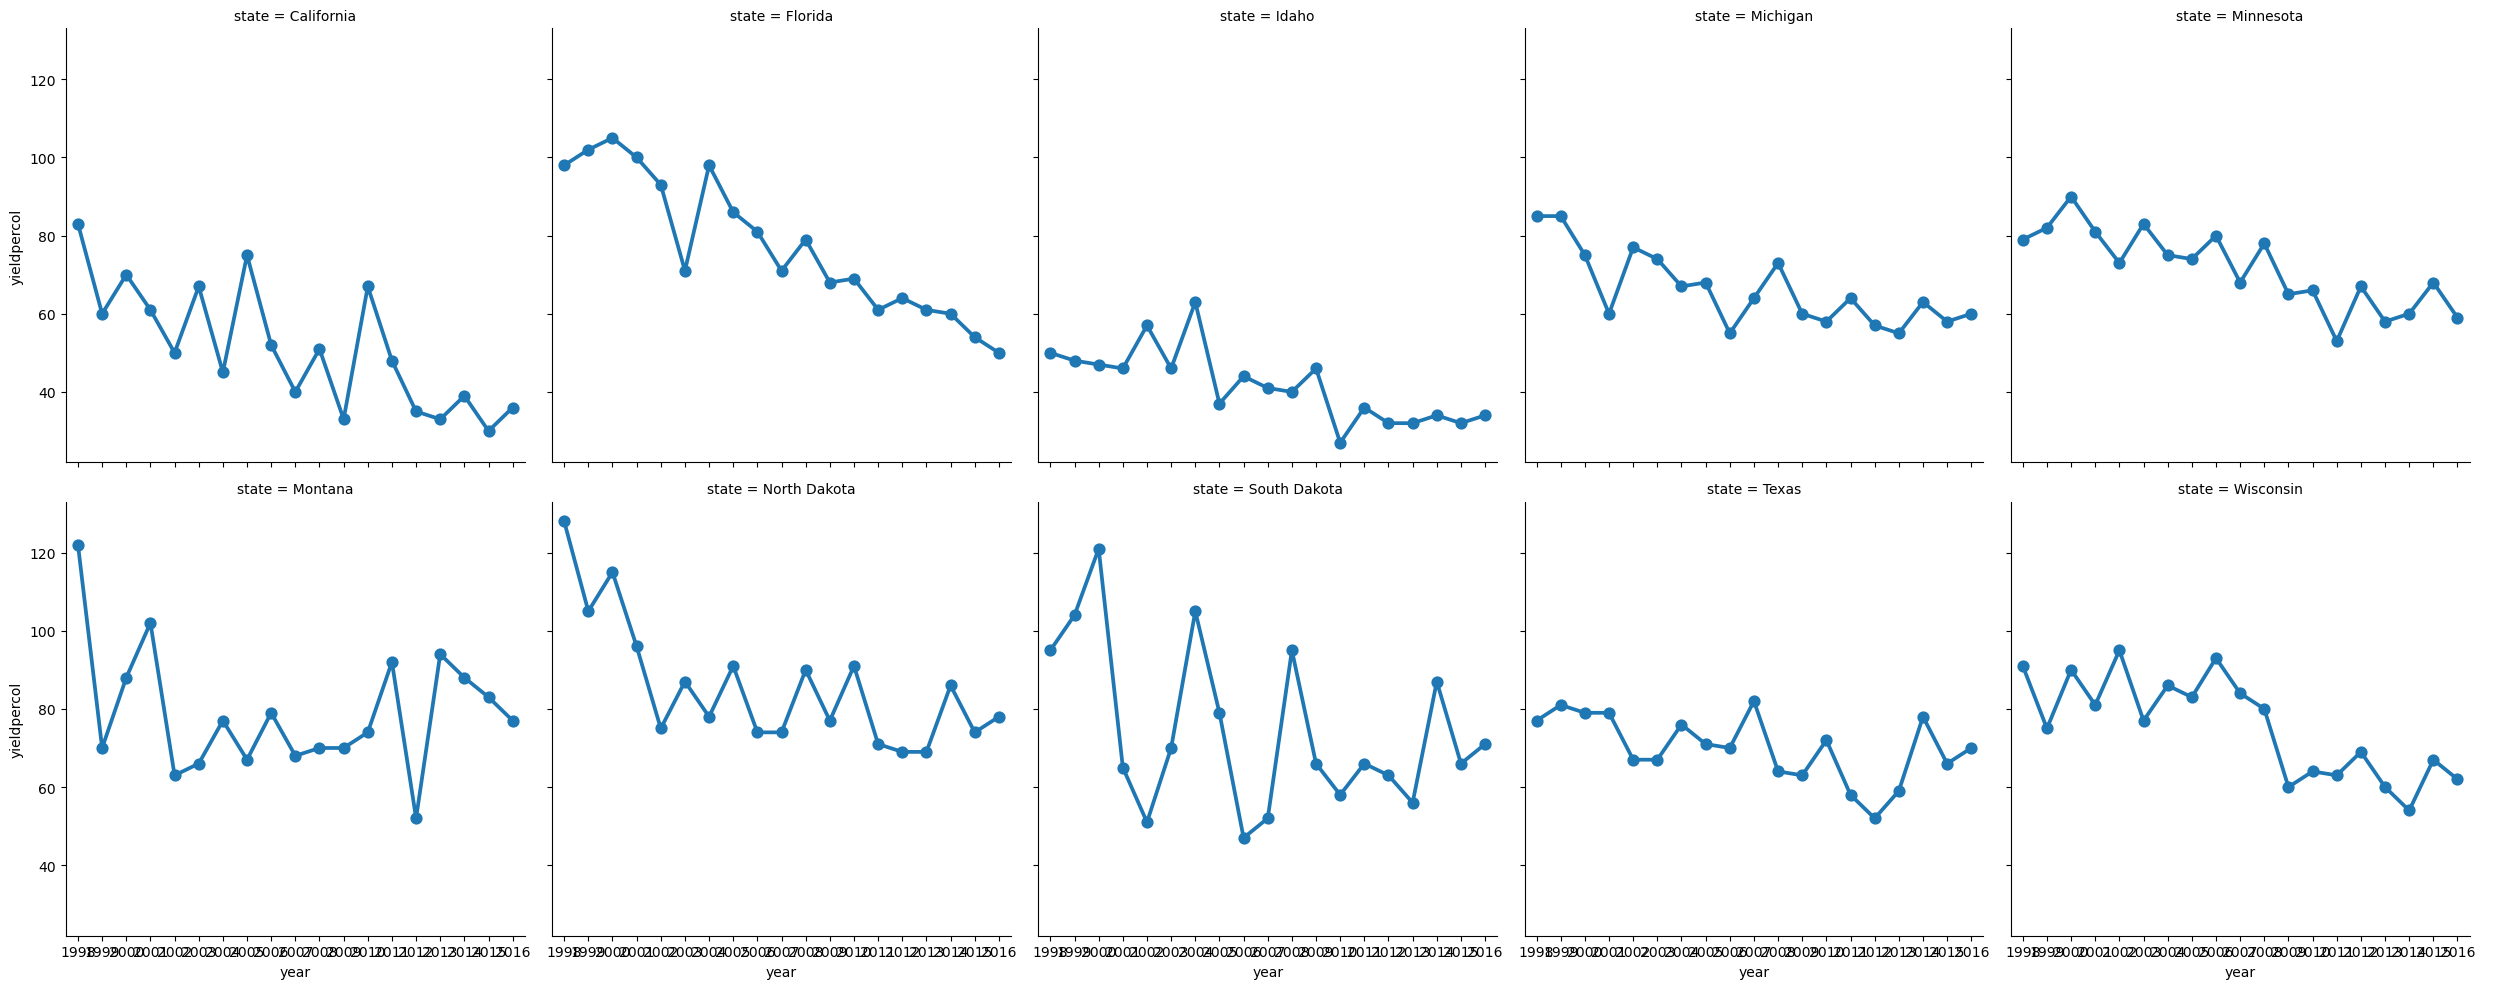

In [258]:
sns.catplot(data=top_10_trend, x='year', y='yieldpercol', col='state', kind='point', col_wrap=5)

1. Clearly, North Dakota has scaled up their number of colonies in order to compensate for the decline in yield per colony which explains the high total Production
2. Most states show a declining trend in Yield per colony
3. Growth is majorly driven by increase in number of colonies

### Key Findings

1. Honey production trends are being driven by a decline in yield per colony rather than a consistent reduction in colony numbers.

2. Yield has decreased steadily over time, with a more noticeable drop after 2006. This indicates a decline in productivity across most states. However, production trends vary significantly by state.

3. States such as California and Florida show a clear decline in production, driven by reductions in both colony count and yield. In contrast, North Dakota has increased production over time, primarily by expanding the number of colonies rather than improving yield.

4. This suggests that states maintaining or growing production are doing so by scaling operations, not by improving efficiency.

5. The impact of CCD appears to be stronger on yield than on colony count. While productivity declines are observed across most states, changes in colony numbers are inconsistent, leading to different production outcomes.

6. From a market perspective, price per pound has increased over time, even as production has declined. This indicates a supply-side constraint, with prices adjusting upward in response. However, the relationship between supply and price is not uniform at the state level.

7. 
#### Overall, the data indicates a shift from efficiency-driven production to scale-driven production, with rising prices reflecting pressure on supply.